In [348]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [349]:
store_info_df = pd.read_csv("store_info.csv")

sales_transactions_df = pd.read_csv("sales_transactions.csv")

# Cleaning store info data set

In [350]:
# Examine data
store_info_df.head()

,store_id,region,manager,store_size,store_type,opening_year
0,S01,East,Manager_A,Medium,Street,2020
1,S02,South,Manager_B,Medium,Street,2017
2,S03,North,Manager_C,Large,Street,2020
3,Store-04,E,Manager_D,Large,Street,2009
4,S05,East,Manager_E,Small,Mall,2022


In [351]:
# Standardize store_id
store_id_map = {
    'Store-04': 'S04',
    '10': 'S10',
    '19': 'S19',
    'unknown': np.nan
}

store_info_df["store_id"] = store_info_df["store_id"].replace(store_id_map)

store_info_df["store_id"].unique()

array(['S01', 'S02', 'S03', 'S04', 'S05', 'S06', 'S07', 'S08', 'S09',
       'S10', 'S11', 'S12', 'S13', 'S14', 'S15', 'S16', 'S17', 'S18',
       'S19', 'S20', 'S21', 'S22', 'S23', 'S24', 'S25', 'S26', 'S27',
       'S28', 'S29', 'S30'], dtype=object)

In [352]:
# Standardize region
store_info_df["region"] = store_info_df["region"].str.capitalize().str.strip()

region_map = {
    'E': 'East',
    'W': 'West',
    'unknown': np.nan
}

store_info_df["region"] = store_info_df["region"].replace(region_map)
store_info_df["region"].unique()

array(['East', 'South', 'North', 'e', 'w', 'West'], dtype=object)

In [353]:
# Standardize manager
store_info_df["manager"] = store_info_df["manager"].str.strip()
store_info_df["manager"].unique()
# Looking at unique values shows some invalid managers including 'Manager_[', 'Manager_\\', 'Manager_]', 'Manager_^'
# I am assuming these are managers that should be included in the data but have invalid characters because alphabet ran out
# I will rename these as 'Manager_AA', 'Manager_AB', 'Manager_AC', 'Manager_AD'

manager_map = {
    'Manager_[': 'Manager_AA',
    'Manager_\\': 'Manager_AB',
    'Manager_]': 'Manager_AC',
    'Manager_^': 'Manager_AD',
    'unknown': np.nan
}

store_info_df["manager"] = store_info_df["manager"].replace(manager_map)

store_info_df["manager"].unique()

array(['Manager_A', 'Manager_B', 'Manager_C', 'Manager_D', 'Manager_E',
       'Manager_F', 'Manager_G', 'Manager_H', 'Manager_I', 'Manager_J',
       'Manager_K', 'Manager_L', 'Manager_M', 'Manager_N', 'Manager_O',
       'Manager_P', 'Manager_Q', 'Manager_R', 'Manager_S', 'Manager_T',
       'Manager_U', 'Manager_V', 'Manager_W', 'Manager_X', 'Manager_Y',
       'Manager_Z', 'Manager_AA', 'Manager_AB', 'Manager_AC',
       'Manager_AD'], dtype=object)

In [354]:
# Clean store_size
store_info_df["store_size"] = store_info_df["store_size"].str.capitalize().str.strip()
store_info_df["store_size"].unique()

array(['Medium', 'Large', 'Small'], dtype=object)

In [355]:
# Clean store_type
store_info_df["store_type"] = store_info_df["store_type"].str.capitalize().str.strip()
store_info_df["store_type"].unique()

array(['Street', 'Mall', 'Outlet'], dtype=object)

In [356]:
# Clean opening_year
store_info_df["opening_year"].unique() # Looks clean

array([2020, 2017, 2009, 2022, 2014, 2021, 2018, 2023, 2019, 2012, 2011,
       2010, 2008, 2013])

In [357]:
# Check for duplicate records
# I am assuming there should not be duplicates under store_id and manager
print(store_info_df['store_id'].duplicated().any()) # No duplicates
print(store_info_df['manager'].duplicated().any()) # No duplicates

False
False


In [358]:
# Check for missing values
store_info_df.isna().sum() # No missing values

store_id        0
region          0
manager         0
store_size      0
store_type      0
opening_year    0
dtype: int64

In [359]:
# Re-examining data to make sure it is cleaned
store_info_df

,store_id,region,manager,store_size,store_type,opening_year
0,S01,East,Manager_A,Medium,Street,2020
1,S02,South,Manager_B,Medium,Street,2017
2,S03,North,Manager_C,Large,Street,2020
3,S04,e,Manager_D,Large,Street,2009
4,S05,East,Manager_E,Small,Mall,2022
5,S06,East,Manager_F,Medium,Mall,2020
6,S07,North,Manager_G,Large,Street,2014
7,S08,South,Manager_H,Medium,Outlet,2021
8,S09,East,Manager_I,Medium,Mall,2018
9,S10,South,Manager_J,Medium,Street,2023


# Cleaning sales transactions data set

In [360]:
# Examining data
sales_transactions_df.head()

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27 00:00:00,Sports,2,activepro,East,59.53,121.7,31,2.76,73.19 CAD
1,T000763,S18,2025-02-14 00:00:00,Beauty,2,Glow Works,West,17.62,40.84,10,NaN,119.32
2,T000623,S03,NaN,Electronics,1,NORTHSTAR,North,235.26,308.8,145,4.66,103.05
3,T000827,S27,2025-01-06 00:00:00,Grocery,2,FreshFarm,West,6.41,10.74,14,4.56,125.6
4,T000175,S01,2025-05-06 00:00:00,Electronics,8,NorthStar,East,231.33,289.13,48,5.34,113.35


In [361]:
# Cleaning transaction_id

# It is a character data type with a capital T followed by numbers
sales_transactions_df["transaction_id"] = sales_transactions_df["transaction_id"].str.capitalize().str.strip()

# There should not be any duplicates, assuming there is a unique id for each transaction
print(store_info_df["store_id"].duplicated().any()) # No duplicates

# Checking for invalid values
print(sum(sales_transactions_df["unit_cost"].isna())) # 53 invalid

# Removing invalid rows
sales_transactions_df = sales_transactions_df.dropna(subset=["unit_cost"])

sales_transactions_df["transaction_id"].unique()

False
53


array(['T000571', 'T000763', 'T000623', ..., 'T000716', 'T000678',
       'T002178'], shape=(2948,), dtype=object)

In [362]:
# Cleaning store_id

# It is a character data type with a capital S followed by numbers
sales_transactions_df["store_id"] = sales_transactions_df["store_id"].str.capitalize().str.strip() 

# Standardize to S[number] format
sales_transactions_df["store_id"] = sales_transactions_df["store_id"] = "S" + sales_transactions_df["store_id"].astype(str).str.extract(r"(\d+)")[0]

# Checking for invalid values
print(sum(sales_transactions_df["store_id"].isna())) # 0 invalid

sales_transactions_df["store_id"].unique()

0


array(['S06', 'S18', 'S03', 'S27', 'S01', 'S24', 'S28', 'S05', 'S12',
       'S21', 'S15', 'S11', 'S23', 'S16', 'S20', 'S02', 'S22', 'S10',
       'S07', 'S13', 'S26', 'S19', 'S08', 'S04', 'S09', 'S14', 'S29',
       'S25', 'S17', 'S30'], dtype=object)

In [363]:
# Cleaning sale_date

# Character data type
sales_transactions_df["sale_date"] = sales_transactions_df["sale_date"].str.strip() 

# Many dates have time, assuming it is unneeded as it is all 0s (00:00:00) and date does not typically include time
# Removing time from dates
sales_transactions_df["sale_date"] = sales_transactions_df["sale_date"].str.replace(" 00:00:00", "", regex=False)

# Dates are in 3 formats (YYYY-MM-DD, DD-Mon-YYYY, MM/DD/YYYY)
# Invalid values include 'not available', NaN, and impossible dates like Feb 30
# Standardize formats to YYYY-MM-DD and remove invalid values
sales_transactions_df["sale_date"] = pd.to_datetime(
    sales_transactions_df["sale_date"],
    format="mixed",
    errors="coerce"
)
sales_transactions_df["sale_date"] = sales_transactions_df["sale_date"].dt.strftime("%Y-%m-%d")

# Checking for invalid values
print(sum(sales_transactions_df["sale_date"].isna())) # 60 invalid

# Removing invalid rows
sales_transactions_df = sales_transactions_df.dropna(subset=["sale_date"])

sales_transactions_df["sale_date"].unique() 

60


array(['2025-06-27', '2025-02-14', '2025-01-06', '2025-05-06',
       '2025-01-04', '2025-01-26', '2025-05-13', '2025-06-01',
       '2025-04-02', '2025-01-07', '2025-04-04', '2025-04-07',
       '2025-05-21', '2025-06-13', '2025-05-08', '2025-02-20',
       '2025-04-06', '2025-06-22', '2025-06-02', '2025-05-11',
       '2025-03-22', '2025-03-08', '2025-04-26', '2025-05-05',
       '2025-01-29', '2025-02-18', '2025-02-21', '2025-01-21',
       '2025-01-10', '2025-01-14', '2025-02-08', '2025-06-03',
       '2025-05-22', '2025-01-11', '2025-03-25', '2025-01-25',
       '2025-02-26', '2025-04-05', '2025-01-22', '2025-01-09',
       '2025-06-23', '2025-05-01', '2025-06-29', '2025-02-23',
       '2025-01-27', '2025-05-03', '2025-05-28', '2025-04-20',
       '2025-06-20', '2025-03-21', '2025-01-19', '2025-03-06',
       '2025-04-22', '2025-03-05', '2025-04-14', '2025-06-07',
       '2025-03-14', '2025-05-31', '2025-04-25', '2025-05-04',
       '2025-02-06', '2025-02-05', '2025-04-11', '2025-

In [364]:
# Cleaning product_category
sales_transactions_df["product_category"] = sales_transactions_df["product_category"].str.capitalize().str.strip()

product_category_map = {
    'Sporting goods': 'Sports',
    'Groceries': 'Grocery',
    'Food': 'Grocery',
    'Electronic': 'Electronics',
    'Home goods': 'Home',
    'Clothing': 'Apparel',
    'Cosmetics': 'Beauty',
    'electronics': 'Electronics',
    'unknown': np.nan
}

sales_transactions_df["product_category"] = sales_transactions_df["product_category"].replace(product_category_map)

# Checking for invalid values
print(sum(sales_transactions_df["unit_cost"].isna())) # 0 invalid

sales_transactions_df["product_category"].unique() 

0


array(['Sports', 'Beauty', 'Grocery', 'Electronics', 'Home', 'Apparel'],
      dtype=object)

In [365]:
# Cleaning quantity

# Convert to numeric
sales_transactions_df["quantity"] = sales_transactions_df["quantity"].replace({
    "two": "2",
    "unknown": np.nan
})

sales_transactions_df["quantity"] = pd.to_numeric(sales_transactions_df["quantity"], errors="coerce")

print(len(sales_transactions_df[sales_transactions_df["quantity"] < 0])) # 43 negative values (invalid)

# Remove rows with negative quantities, I am assuming these products were not bought and are unneeded
sales_transactions_df = sales_transactions_df[sales_transactions_df["quantity"] >= 0]

# Checking for invalid values
print(sum(sales_transactions_df["quantity"].isna())) # 0 invalid

sales_transactions_df["quantity"].unique()

43
0


array([ 2.,  8.,  4.,  7.,  1.,  9.,  3.,  0.,  6.,  5., 10.])

In [366]:
# Cleaning supplier

# Remove leading/trailing spaces and standardize capitalization
sales_transactions_df["supplier"] = sales_transactions_df["supplier"].str.strip().str.lower()

# Remove spaces and hyphens
sales_transactions_df["supplier"] = (
    sales_transactions_df["supplier"]
    .str.replace(" ", "", regex=False)
    .str.replace("-", "", regex=False)
)

# Convert to consistent names
sales_transactions_df["supplier"] = sales_transactions_df["supplier"].replace({
    "activepro": "ActivePro",
    "glowworks": "GlowWorks",
    "northstar": "NorthStar",
    "freshfarm": "FreshFarm",
    "budgetsource": "BudgetSource",
    "stylehub": "StyleHub"
})

# Checking for invalid values
print(sum(sales_transactions_df["supplier"].isna())) # 0 invalid

sales_transactions_df["supplier"].unique()

0


array(['ActivePro', 'GlowWorks', 'FreshFarm', 'NorthStar', 'BudgetSource',
       'StyleHub'], dtype=object)

In [367]:
# Cleaning region
sales_transactions_df["region"].unique()
# No cleaning was required. 
# The column contained four consistent and valid categories: East, West, North, and South.

array(['East', 'West', 'North', 'South'], dtype=object)

In [368]:
# Cleaning unit_cost
# Remove spaces, $ signs, and "CAD"
sales_transactions_df["unit_cost"] = (
    sales_transactions_df["unit_cost"]
    .astype(str)
    .str.strip()
    .str.replace("$", "", regex=False)
    .str.replace(" CAD", "", regex=False)
)

# Convert to numeric
sales_transactions_df["unit_cost"] = pd.to_numeric(sales_transactions_df["unit_cost"], errors="coerce")

# Checking for invalid values
print(sum(sales_transactions_df["unit_cost"].isna())) # 22 invalid

# Removing invalid rows
sales_transactions_df = sales_transactions_df.dropna(subset=["unit_cost"])

sales_transactions_df["unit_cost"].unique()

22


array([59.53, 17.62,  6.41, ..., 60.44, 28.66,  6.61], shape=(2178,))

In [369]:
# Cleaning unit_price
# Remove spaces, $ signs, and "CAD"
sales_transactions_df["unit_price"] = (
    sales_transactions_df["unit_price"]
    .astype(str)
    .str.strip()
    .str.replace("$", "", regex=False)
    .str.replace(" CAD", "", regex=False)
)

# Convert to numeric
sales_transactions_df["unit_price"] = pd.to_numeric(sales_transactions_df["unit_price"], errors="coerce")

# Check for invalid values
print(sales_transactions_df["unit_price"].isna().sum()) # 0 invalid values

sales_transactions_df["unit_price"].unique()

0


array([121.7 ,  40.84,  10.74, ..., 279.87, 118.09,  60.4 ], shape=(2433,))

In [370]:
# Cleaning inventory_level

# Replace text with missing values
sales_transactions_df["inventory_level"] = sales_transactions_df["inventory_level"].replace("unknown", np.nan)

# Convert to numeric
sales_transactions_df["inventory_level"] = pd.to_numeric(sales_transactions_df["inventory_level"], errors="coerce")

# Replace negative inventory levels with missing values
sales_transactions_df.loc[sales_transactions_df["inventory_level"] < 0, "inventory_level"] = np.nan

# Checking for invalid values
print(sum(sales_transactions_df["inventory_level"].isna())) # 105 invalid

# Removing invalid rows
sales_transactions_df = sales_transactions_df.dropna(subset=["inventory_level"])

sales_transactions_df["inventory_level"].unique()

105


array([ 31.,  10.,  14.,  48.,  63.,  19.,  83.,  50.,  20.,  76., 105.,
       155., 121., 146., 147.,  73.,  24., 123.,  40., 120.,  35., 139.,
        89.,  68.,   0.,   3.,  70.,   1.,  87.,  25., 114., 144.,  88.,
        85.,  21., 156.,  15.,  64.,  54.,  56.,  44.,  16.,  11.,  47.,
        34., 154., 134., 106.,  37., 145., 153., 107., 151.,  39., 108.,
        32.,  95.,  49.,  33.,  78.,  38.,  26., 133., 128.,  97., 116.,
       103.,  42., 110.,  59., 131.,  52.,  82., 148.,  29., 149.,  51.,
        17., 112., 136., 111., 104., 124., 138.,  13., 119., 117.,  80.,
        69.,  23.,  12.,   7.,  36.,  28., 140.,   8.,   6., 100.,  62.,
        93.,  30.,  99.,   2.,  46.,  27.,  18., 135.,  43.,  55., 109.,
       122.,  58.,  60.,  75.,  67., 113.,  22.,  61.,  94., 102.,   4.,
       118.,  96.,  91.,  41.,  90., 159.,  77.,  45., 127., 150.,  65.,
        72.,  71., 125., 130., 137., 115.,   9.,  74., 126.,  81., 101.,
       129.,  57., 142., 141., 157.,   5., 143.,  8

In [371]:
# Cleaning labour_hours

# Replace "unknown" with missing values
sales_transactions_df["labour_hours"] = sales_transactions_df["labour_hours"].replace("unknown", np.nan)

# Convert to numeric
sales_transactions_df["labour_hours"] = pd.to_numeric(sales_transactions_df["labour_hours"], errors="coerce")

# Replace negative values with missing values
sales_transactions_df.loc[sales_transactions_df["labour_hours"] < 0, "labour_hours"] = np.nan


# Checking for invalid values
print(sum(sales_transactions_df["labour_hours"].isna())) # 82 invalid

# Removing invalid rows
sales_transactions_df = sales_transactions_df.dropna(subset=["labour_hours"])

sales_transactions_df["labour_hours"].unique()



82


array([2.76, 4.56, 5.34, 3.55, 4.22, 4.21, 3.75, 5.68, 5.06, 3.81, 4.78,
       5.82, 5.51, 3.23, 5.33, 3.73, 4.48, 4.08, 4.24, 4.4 , 4.74, 4.34,
       4.06, 6.96, 4.82, 5.49, 3.29, 4.61, 4.28, 3.52, 5.2 , 5.18, 5.24,
       6.66, 4.59, 2.17, 5.38, 5.29, 5.47, 3.1 , 3.94, 4.25, 5.22, 3.09,
       5.64, 5.43, 4.38, 3.24, 2.79, 4.23, 3.99, 5.42, 4.52, 3.05, 4.05,
       6.16, 4.3 , 6.58, 5.71, 5.05, 5.1 , 4.18, 5.15, 5.5 , 3.92, 2.93,
       5.74, 3.68, 6.71, 5.52, 4.73, 3.57, 5.84, 4.54, 4.98, 4.8 , 4.72,
       5.91, 4.9 , 7.53, 5.66, 3.67, 2.58, 4.89, 2.26, 5.41, 5.14, 5.32,
       5.78, 5.7 , 3.4 , 3.15, 4.46, 2.6 , 4.17, 3.62, 4.11, 2.72, 4.57,
       5.23, 3.06, 4.31, 5.26, 4.53, 3.96, 2.23, 4.  , 3.87, 4.64, 3.63,
       5.27, 2.96, 4.69, 3.79, 3.71, 2.14, 4.84, 3.53, 6.14, 6.69, 5.11,
       4.63, 3.08, 3.01, 5.69, 3.18, 5.02, 5.12, 4.91, 7.05, 3.39, 5.63,
       6.31, 6.34, 3.48, 4.07, 5.04, 2.67, 4.16, 5.16, 4.55, 4.62, 4.45,
       5.09, 3.65, 4.19, 3.49, 5.81, 2.37, 4.36, 3.

In [372]:
# Cleaning labour_cost
# Remove spaces, $ signs, and "CAD"
sales_transactions_df["labour_cost"] = (
    sales_transactions_df["labour_cost"]
    .astype(str)
    .str.strip()
    .str.replace("$", "", regex=False)
    .str.replace(" CAD", "", regex=False)
)

# Convert to numeric
sales_transactions_df["labour_cost"] = pd.to_numeric(sales_transactions_df["labour_cost"], errors="coerce")

# Checking for invalid values
print(sales_transactions_df["labour_cost"].isna().sum()) # 0 invalid values


0


In [373]:
# Re-examining data to make sure it is cleaned
sales_transactions_df

,transaction_id,store_id,sale_date,product_category,quantity,supplier,region,unit_cost,unit_price,inventory_level,labour_hours,labour_cost
0,T000571,S06,2025-06-27,Sports,2.0,ActivePro,East,59.53,121.70,31.0,2.76,73.19
3,T000827,S27,2025-01-06,Grocery,2.0,FreshFarm,West,6.41,10.74,14.0,4.56,125.60
4,T000175,S01,2025-05-06,Electronics,8.0,NorthStar,East,231.33,289.13,48.0,5.34,113.35
5,T000865,S24,2025-01-04,Electronics,4.0,NorthStar,West,254.64,340.15,63.0,3.55,99.26
6,T001088,S27,2025-01-26,Home,2.0,BudgetSource,West,51.48,100.44,19.0,4.22,134.57
...,...,...,...,...,...,...,...,...,...,...,...,...
3080,T000913,S12,2025-03-25,Home,1.0,BudgetSource,South,38.99,69.56,14.0,3.35,82.53
3081,T001544,S24,2025-02-05,Electronics,2.0,NorthStar,West,226.30,279.87,25.0,4.74,146.84
3082,T000716,S30,2025-04-12,Sports,1.0,ActivePro,West,60.44,118.09,1.0,3.47,115.96
3083,T000678,S01,2025-06-27,Apparel,1.0,StyleHub,East,28.66,60.40,23.0,5.74,137.09


In [374]:
# Create a revenue column
sales_transactions_df["revenue"] = sales_transactions_df["quantity"] * sales_transactions_df["unit_price"]

# Calculate total revenue
total_revenue = sales_transactions_df["revenue"].sum()

print(f"Total Revenue: ${total_revenue:,.2f}")

Total Revenue: $873,426.28


In [375]:
# Revenue
sales_transactions_df["revenue"] = sales_transactions_df["quantity"] * sales_transactions_df["unit_price"]

# Cost of goods sold
sales_transactions_df["cogs"] = sales_transactions_df["quantity"] * sales_transactions_df["unit_cost"]

# Gross profit per transaction
sales_transactions_df["gross_profit"] = sales_transactions_df["revenue"] - sales_transactions_df["cogs"]

# Total gross profit
total_gross_profit = sales_transactions_df["gross_profit"].sum()

print(f"Total Gross Profit: ${total_gross_profit:,.2f}")

Total Gross Profit: $294,167.75


1. How many duplicate transactions were removed? - None
2. How many invalid quantity records were removed? - 401 from sales_transactions_df, none from store_info_df
3. How many records remain after cleaning? 2684 in sales_transactions_df, 30
4. What is the total revenue? $873,426.28
5. What is the total gross profit? $294,167.75

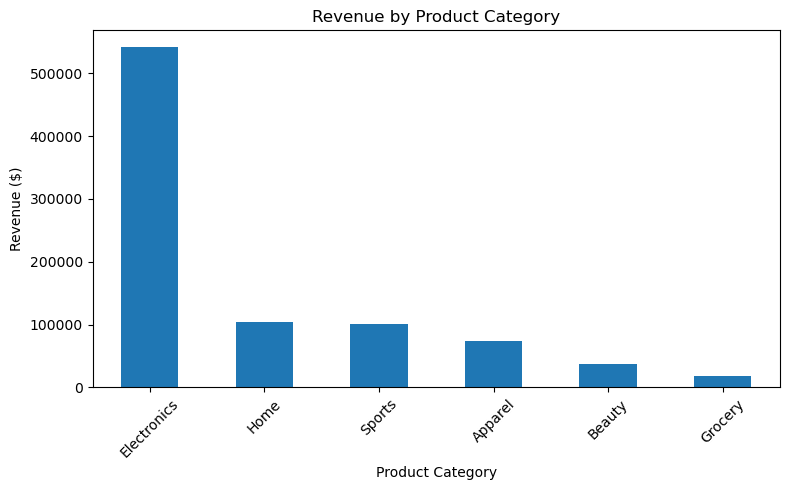

In [376]:
revenue_by_category = (
    sales_transactions_df.groupby("product_category")["revenue"]
    .sum()
    .sort_values(ascending=False)
)

revenue_by_category.plot(
    kind="bar",
    figsize=(8,5),
    title="Revenue by Product Category"
)
plt.ylabel("Revenue ($)")
plt.xlabel("Product Category")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

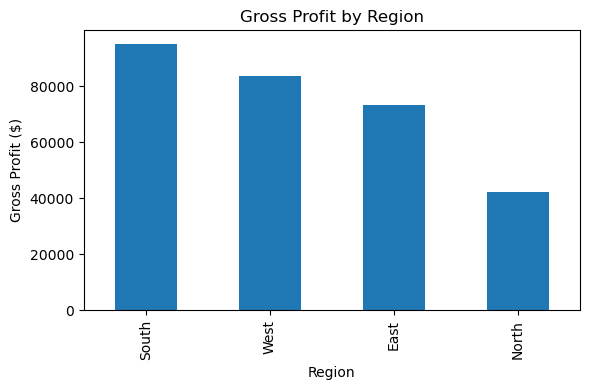

In [377]:
sales_transactions_df["gross_profit"] = (
    sales_transactions_df["quantity"] * (sales_transactions_df["unit_price"] - sales_transactions_df["unit_cost"])
)

profit_by_region = (
    sales_transactions_df.groupby("region")["gross_profit"]
    .sum()
    .sort_values(ascending=False)
)

profit_by_region.plot(
    kind="bar",
    figsize=(6,4),
    title="Gross Profit by Region"
)
plt.ylabel("Gross Profit ($)")
plt.xlabel("Region")
plt.tight_layout()
plt.show()

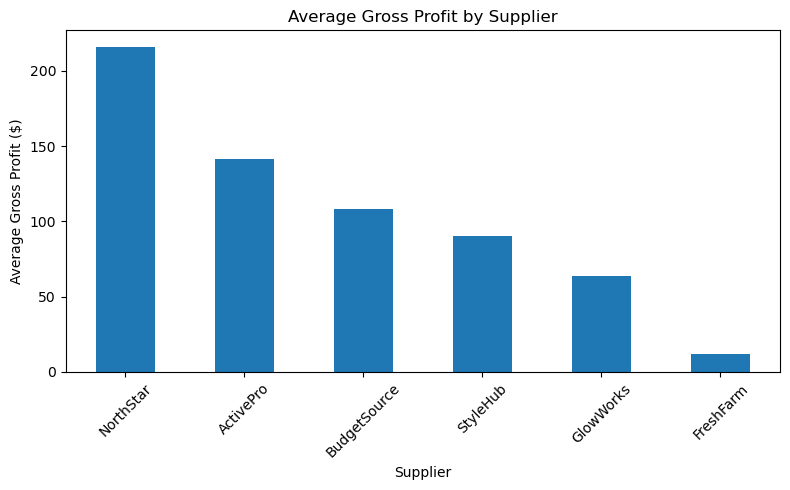

In [378]:
supplier_profit = (
    sales_transactions_df.groupby("supplier")["gross_profit"]
    .mean()
    .sort_values(ascending=False)
)

supplier_profit.plot(
    kind="bar",
    figsize=(8,5),
    title="Average Gross Profit by Supplier"
)
plt.ylabel("Average Gross Profit ($)")
plt.xlabel("Supplier")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

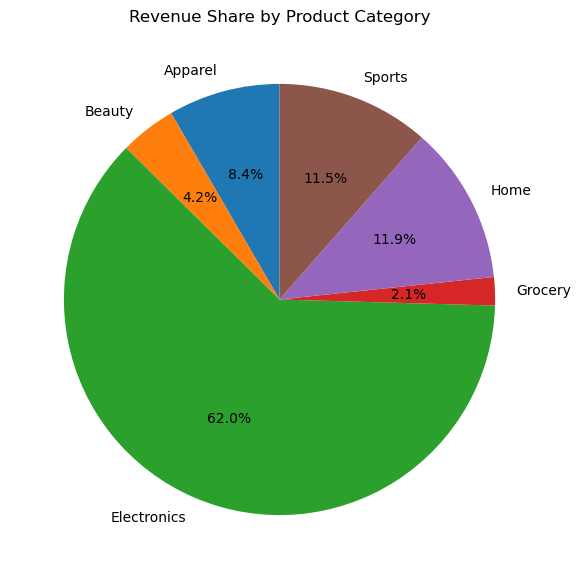

In [379]:
revenue_by_category = sales_transactions_df.groupby("product_category")["revenue"].sum()

plt.figure(figsize=(7,7))
plt.pie(
    revenue_by_category,
    labels=revenue_by_category.index,
    autopct="%1.1f%%",
    startangle=90
)
plt.title("Revenue Share by Product Category")
plt.show()

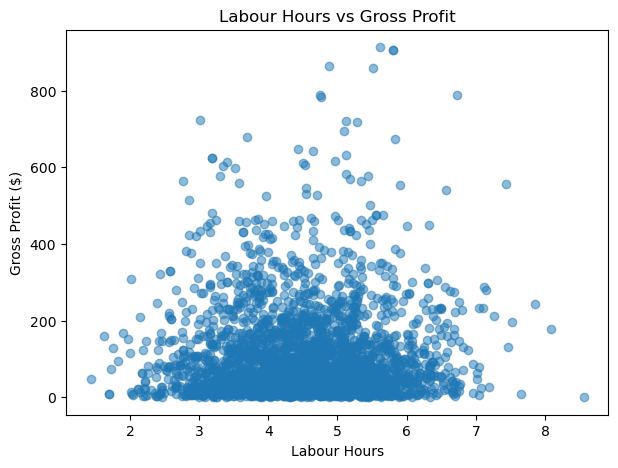

In [380]:
plt.figure(figsize=(7,5))
plt.scatter(sales_transactions_df["labour_hours"], sales_transactions_df["gross_profit"], alpha=0.5)
plt.title("Labour Hours vs Gross Profit")
plt.xlabel("Labour Hours")
plt.ylabel("Gross Profit ($)")
plt.show()

Consulting Summary

The analysis indicates that the Electronics category is the company's primary source of revenue, accounting for approximately 62% of total sales. In comparison, Grocery and Beauty contribute only a small share of revenue, suggesting opportunities to improve the performance of these product categories or reconsider their strategic importance.

Regional performance varies noticeably, with the South region generating the highest gross profit, followed by the West and East regions. The North region produces substantially lower profits, indicating that management should investigate factors such as sales volume, pricing strategies, or operational efficiency to improve performance.

Supplier analysis shows that NorthStar consistently delivers the highest average gross profit per transaction, making it the strongest-performing supplier in the dataset. Conversely, FreshFarm generates the lowest average gross profit, suggesting that its pricing, product mix, or supplier agreement may require review.

Finally, the scatter plot comparing labour hours and gross profit reveals no strong linear relationship between the two variables. Transactions requiring more labour hours do not consistently generate higher profits, indicating that labour time alone is not a reliable predictor of profitability. Improving operational efficiency and focusing on high-margin products and suppliers may have a greater impact on overall business performance than simply increasing labour investment.

In [381]:
sales_transactions_df.to_csv("cleaned_sales_transactions.csv", index=False)
store_info_df.to_csv("cleaned_store_info.csv", index=False)